In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

import math

def plot_heatmap(f, inp_range=(-np.pi, np.pi), num_range=(-np.pi, np.pi), n=300, title=None, figsize=(7, 6)):
    """Plot f(inp, num) as a heatmap with PiYG diverging colormap, centered at 0."""
    inp = np.linspace(*inp_range, n)
    num = np.linspace(*num_range, n)
    INP, NUM = np.meshgrid(inp, num, indexing='ij')
    Z = f(INP, NUM)

    vmax = np.max(np.abs(Z))
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(Z, extent=[*num_range, *inp_range], origin='lower', cmap='PiYG', vmin=-vmax, vmax=vmax, aspect='auto')
    fig.colorbar(im, ax=ax)
    ax.set_xlabel('num')
    ax.set_ylabel('inp')
    ax.invert_yaxis()
    if title:
        ax.set_title(title)
    plt.show()

def plot_heatmap_torch(f, inp_range=(-torch.pi, torch.pi), num_range=(-torch.pi, torch.pi), n=300, title=None, figsize=(7, 6), cmap="PiYG"):
    """Plot f(inp, num) as a heatmap with PiYG diverging colormap, centered at 0. Expects f to return a torch tensor."""
    inp = torch.linspace(inp_range[0], inp_range[1], n)
    num = torch.linspace(num_range[0], num_range[1], n)
    INP, NUM = torch.meshgrid(inp, num, indexing='ij')
    Z = f(INP, NUM)

    # vmax = Z.abs().max().item()
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(Z.detach().cpu().numpy(), extent=[*num_range, *inp_range], origin='lower', cmap=cmap, aspect='auto') # vmin=-vmax, vmax=vmax,
    fig.colorbar(im, ax=ax)
    ax.set_xlabel('num')
    ax.set_ylabel('inp')
    ax.invert_yaxis()
    ax.set_xticks(list(range(math.ceil(num_range[0]), math.floor(num_range[1]) + 1)))
    ax.set_yticks(list(range(math.ceil(inp_range[0]), math.floor(inp_range[1]) + 1)))
    if title:
        ax.set_title(title)
    plt.show()


<>:36: SyntaxWarning: invalid escape sequence '\p'
<>:36: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1600/1179542626.py:36: SyntaxWarning: invalid escape sequence '\p'
  title = "what claude said f_i(a,b) is: cos(2pi/5 * (a+b-(\phi_a+\phi_b)))"; cmap = "PiYG"


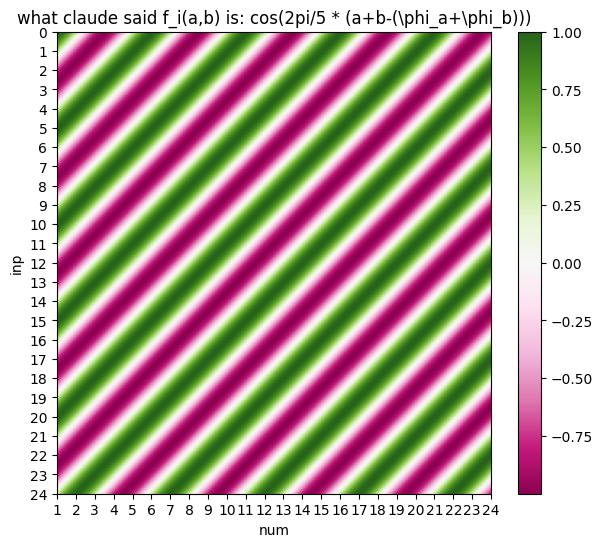

In [ ]:
# lambda x, y: np.cos(x) - np.cos(y) dumb example

twopiover5 = (2 * np.pi) / 5
phase_inp = 4
phase_num = 2
cmap = "PiYG"

# simulation of n2404
title = "~N2404: silu(cos(a-phi_a)) * cos(b-phi_b)"; cmap = "PiYG"
# f = lambda inp, num: 0.5 * (np.cos(twopiover5 * (inp+num) - 6*twopiover5) - np.cos(twopiover5 * (inp-num) - 2*twopiover5))
# f = lambda inp, num: 0.5 * (np.cos(twopiover5 * (inp+num) - (phase_inp + phase_num)*twopiover5) - np.cos(twopiover5 * (inp-num) - (phase_inp - phase_num)*twopiover5))
# f = lambda inp, num: (0.5 * (torch.cos(twopiover5 * (inp+num) - (phase_inp + phase_num)*twopiover5) - torch.cos(twopiover5 * (inp-num) - (phase_inp - phase_num)*twopiover5))) * torch.sigmoid(torch.cos(twopiover5 * (inp - phase_inp)))
f = lambda inp, num: torch.nn.functional.silu(torch.cos(twopiover5 * (inp - phase_inp))) * torch.cos(twopiover5 * (num - phase_num))

# title = "~N2404 gate: silu(cos(a-phi_a))"; cmap = "Blues"
# f = lambda inp, num: torch.nn.functional.silu(torch.cos(twopiover5 * (inp - phase_inp))) # torch.cos(twopiover5 * (num - phase_num))

title = "~N2404 up: cos(b-phi_b))"; cmap = "PRGn"
f = lambda inp, num: torch.cos(twopiover5 * (num - phase_num))

# egg carton (gingham without silu)
# f = lambda inp, num: torch.cos(twopiover5 * (inp - 1.5))+torch.cos(twopiover5 * (num - 3.5)); cmap = "PRGn"; title="egg carton: cos(a-phi_a) + cos(b-phi_b)"

# gingham
# f = lambda inp, num: torch.nn.functional.silu(torch.cos(twopiover5 * (inp - 1.5))+torch.cos(twopiover5 * (num - 3.5))); cmap = "Blues"; title="gingham: silu(cos(a-phi_a) + cos(b-phi_b))"

# the holy grail end goal. we want f(a,b) = (a + b) % 5.
# title = "desired end result: (a+b) % 5"; cmap = "Purples"
# f = lambda inp, num: (inp + num) % 5

# desired end result as a sinusoid:  ???
# title = "desired end result: cos(2pi/5*(a+b))"; cmap = "PiYG"
# f = lambda inp, num: torch.cos(twopiover5 * (inp+num))

# what claude said f_i(a,b) is
title = "what claude said f_i(a,b) is: cos(2pi/5 * (a+b-(\phi_a+\phi_b)))"; cmap = "PiYG"
f = lambda inp, num: torch.cos(twopiover5 * (inp+num-(phase_inp+phase_num)))


plot_heatmap_torch(
    f,
    inp_range=(0, 24),
    num_range=(1, 24),
    title=title,
    cmap=cmap
)

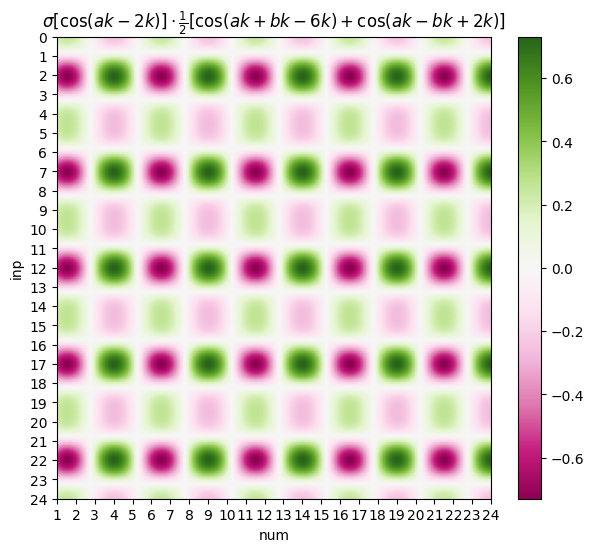

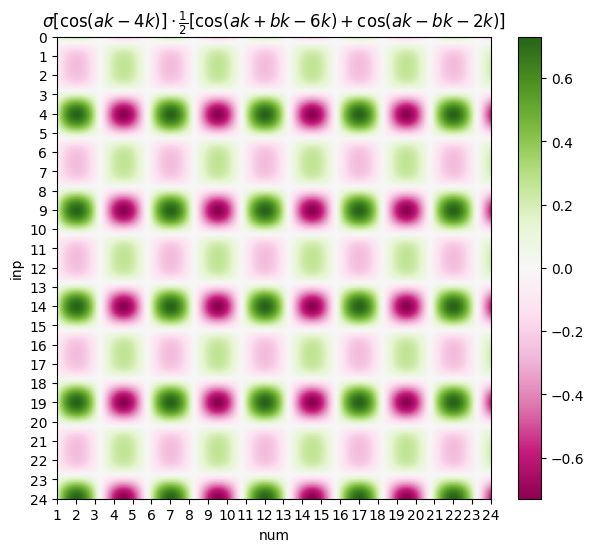

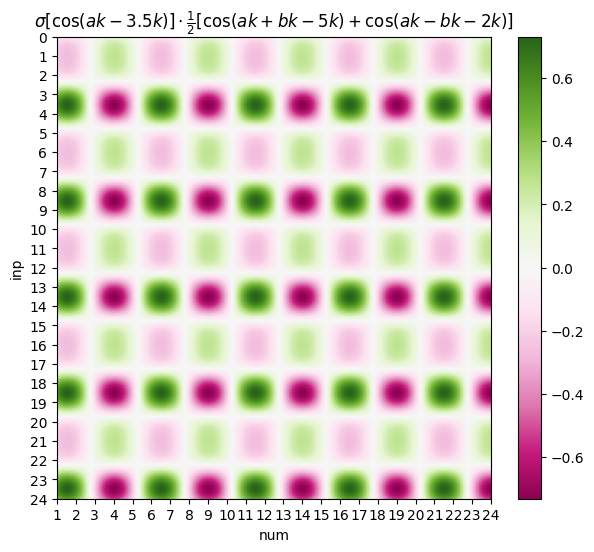

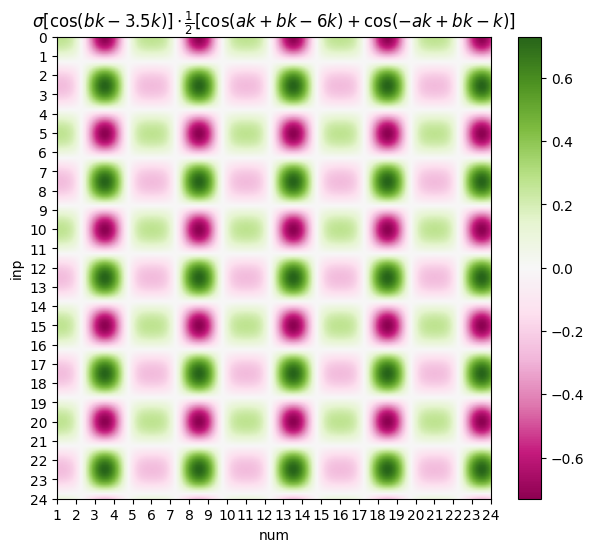

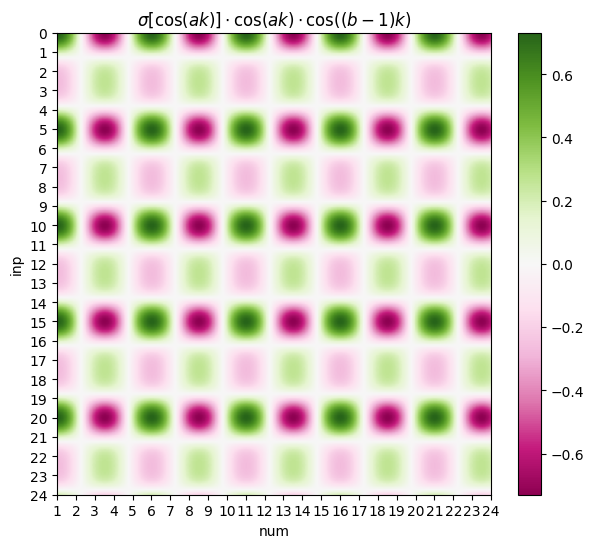

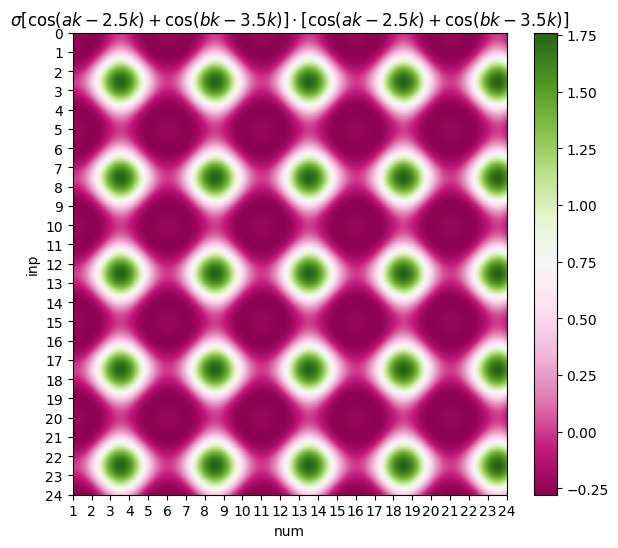

In [ ]:

# functions for all the neurons
k = twopiover5  # 2π/5
sig = torch.sigmoid

functions = [
    # 1: σ[cos(ak-2k)] · ½[cos(ak+bk-6k) + cos(ak-bk+2k)]
    lambda a, b: sig(torch.cos(a*k - 2*k)) * 0.5 * (torch.cos(a*k + b*k - 6*k) + torch.cos(a*k - b*k + 2*k)),
    # 2: σ[cos(ak-4k)] · ½[cos(ak+bk-6k) + cos(ak-bk-2k)]
    lambda a, b: sig(torch.cos(a*k - 4*k)) * 0.5 * (torch.cos(a*k + b*k - 6*k) + torch.cos(a*k - b*k - 2*k)),
    # 3: σ[cos(ak-3.5k)] · ½[cos(ak+bk-5k) + cos(ak-bk-2k)]
    lambda a, b: sig(torch.cos(a*k - 3.5*k)) * 0.5 * (torch.cos(a*k + b*k - 5*k) + torch.cos(a*k - b*k - 2*k)),
    # 4: σ[cos(bk-3.5k)] · ½[cos(ak+bk-6k) + cos(-ak+bk-k)]
    lambda a, b: sig(torch.cos(b*k - 3.5*k)) * 0.5 * (torch.cos(a*k + b*k - 6*k) + torch.cos(-a*k + b*k - k)),
    # 5: σ[cos(ak)] · cos(ak) · cos((b-1)k)
    lambda a, b: sig(torch.cos(a*k)) * torch.cos(a*k) * torch.cos((b - 1)*k),
    # 6: σ[cos(ak-2.5k) + cos(bk-3.5k)] · [cos(ak-2.5k) + cos(bk-3.5k)]
    lambda a, b: sig(torch.cos(a*k - 2.5*k) + torch.cos(b*k - 3.5*k)) * (torch.cos(a*k - 2.5*k) + torch.cos(b*k - 3.5*k)),
]

labels = [
    r"$\sigma[\cos(ak-2k)] \cdot \frac{1}{2}[\cos(ak+bk-6k) + \cos(ak-bk+2k)]$",
    r"$\sigma[\cos(ak-4k)] \cdot \frac{1}{2}[\cos(ak+bk-6k) + \cos(ak-bk-2k)]$",
    r"$\sigma[\cos(ak-3.5k)] \cdot \frac{1}{2}[\cos(ak+bk-5k) + \cos(ak-bk-2k)]$",
    r"$\sigma[\cos(bk-3.5k)] \cdot \frac{1}{2}[\cos(ak+bk-6k) + \cos(-ak+bk-k)]$",
    r"$\sigma[\cos(ak)] \cdot \cos(ak) \cdot \cos((b-1)k)$",
    r"$\sigma[\cos(ak-2.5k)+\cos(bk-3.5k)] \cdot [\cos(ak-2.5k)+\cos(bk-3.5k)]$",
]

for f, label in zip(functions, labels):
    plot_heatmap_torch(
        f,
        inp_range=(0, 24),
        num_range=(1, 24),
        title=label,
        cmap="PiYG",
    )



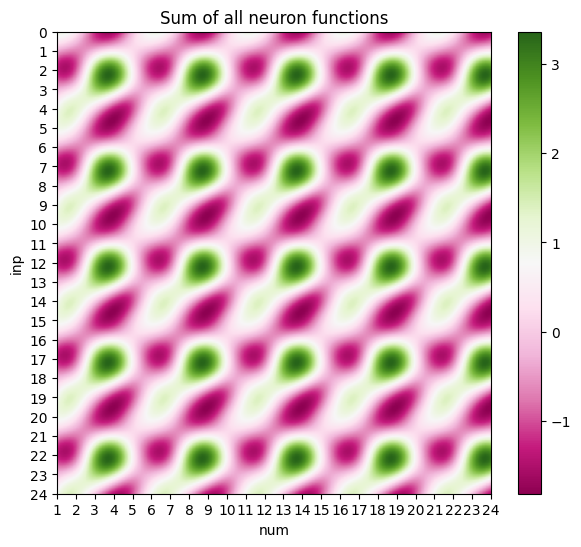

In [ ]:

# sum of all neuron functions
def all_neurons_sum(a, b):
    return sum(f(a, b) for f in functions)

plot_heatmap_torch(
    all_neurons_sum,
    inp_range=(0, 24),
    num_range=(1, 24),
    title="Sum of all neuron functions",
    cmap="PiYG",
)

# Neel Nanda thing

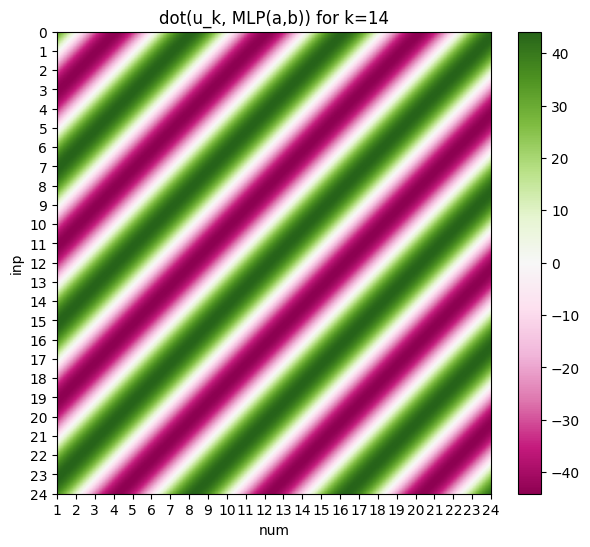

In [ ]:
k = 14
title = f"dot(u_k, MLP(a,b)) for k={k}"; cmap = "PiYG"

w_k = 2 * np.pi * k / 113
f = lambda a, b: 44.1 * torch.cos(w_k * (a+b))


plot_heatmap_torch(
    f,
    inp_range=(0, 24),
    num_range=(1, 24),
    title=title,
    cmap=cmap
)